**Esercizio 1**: quanto costa `dbscan`? 
facendo riferimento al codice sotto, faccio $n$ iterazioni, con $n$ il numero di punti.

l'algoritmo vuole classificare i punti nel seguente modo:
* enumero ed estraggo i punti uno alla volta
* se non e' stato etichettato ed ho abbastanza vicini allora quello diventa un cluster
* se e' un cluster allora devo etichettare i vicini con quel nome

l'algoritmo guarda lo stesso punto al piu' due volte, quando:
* e' stato etichettato come `Noise`
* viene identificato come raggiungibile da qualche core


Dunque ho $n$ iterazioni. Ad ogni iterazione estraggo un punto `p`:
* se `p` non era etichettato, estraggo i punti a distanza `eps` da `p` in tempo $log N$ (`tree.query_ball_point`)
* al caso peggiore ogni nodo e' un cluster formato da solo se stesso

Ogni volta che identifico un cluster lo devo espandere, ipottiziamo che il numero di nodi vicini $N$ sia una costante $c = |N|$ che posso ignorare:
* devo guardare i vicini del nodo per vedere se e' un core e costa sempre `log N`

Dunque il costo e': $O(N * (log N + c log N)) = O(N log N)$

In [11]:
import numpy as np
from scipy.spatial import KDTree

def dbscan(points, eps, min_pts):
    points = np.array(points)

    n = points.shape[0]
    tree = KDTree(points)

    c = -1  # c+1 sarà il 'nome' del prossimo cluster
    labels = [None]*n

    for i, p in enumerate(points):
        if labels[i] != None:
            continue
        N = tree.query_ball_point(p, eps) # indici in points dei punti a distanza eps da p
        if len(N) < min_pts:
            labels[i] = 'Noise'
            continue

        c += 1

        labels[i] = str(c)

        # estensione
        S = set(N) - set([i]) # nel caso medio |N| è considerato costante
        while len(S) > 0:
            j = S.pop()
            if labels[j] == 'Noise':
                labels[j] = str(c)
            if labels[j] != None:
                continue
            labels[j] = str(c)
            N = tree.query_ball_point(points[j], eps)
            if len(N) < min_pts:
                continue
            S = S.union(set(N) - set([j])) # costo lineare in max(S, |N|)
            # S.update( set(N) - set([j]) )  # meglio usare questa: costo lineare in |N|, quindi costante nel caso medio

    return labels


**Esercizio 2**. Si utilizzi il metodo descritto per trovare il valore di `eps` consigliato per i tre dataset dell'esempio precedente.

Sia $C=(x,y)$ il gomito del grafico, il valore da trovare e' $y$ e $x$ sono i punti, dove questi sono ordinati rispettoal  corrispettivo $y$.

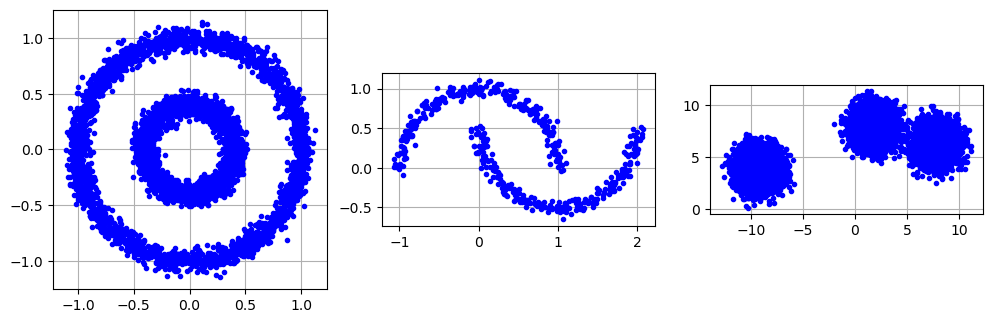

In [12]:
# importa i dati
from sklearn import datasets
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt 

noisy_circles = datasets.make_circles(n_samples=5000, factor=0.4, noise=0.05, random_state=0)
noisy_moons = datasets.make_moons(n_samples=500, noise=0.05, random_state=0)
blobs = datasets.make_blobs(n_samples=15000, center_box=(-10,10), random_state=20)

fig, axs = plt.subplots(1, 3, figsize=(12,8))

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    ax = axs[i]
    ax.scatter([x for x, _ in points], [y for _, y in points], color= 'blue', marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    #ax.axis('off')

0.03842893577658906


/tmp/ipykernel_21347/3601993016.py:35: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_AB.append([np.abs(np.cross(A-B, A-p))/ np.linalg.norm(A-B)


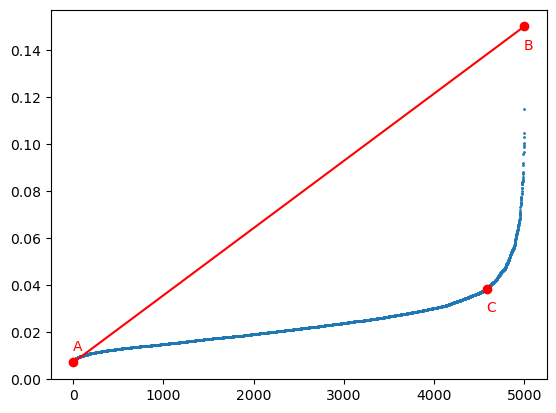

In [13]:
points = noisy_circles[0]
tree = KDTree(points)

min_pts = 6
k_dists = []
for p in points: 
    N = tree.query(p, k=min_pts)
    # mi prendo la piu lontana
    min_pts_dist = N[0][-1]
    k_dists.append(min_pts_dist)

k_dists.sort()

# RETTA ROSSA
# disegna la retta, sulle x trovo gli indici dei punti, ossia questi sono numerati in [1,N] sull'asse delle x
# sulle y trovo la k_dist. Nota che sono stati ordinati!
plt.plot([0, len(k_dists)-1], [k_dists[0], k_dists[-1]], c='red')
plt.scatter(np.arange(len(k_dists)), k_dists, s = 1)


# A, B
A = np.array( (0.0, k_dists[0]))
# -1.0: perche ora si conta a partire da 0??
B = np.array( (len(k_dists)-1.0, k_dists[-1]))

plt.scatter(A[0], A[1], color='red')
plt.text(A[0]-1, A[1]+.005, 'A', color='red')
plt.scatter(B[0], B[1], color='red')
plt.text(B[0]-1, B[1]-.01, 'B', color='red')
dist_AB = []
for i, d in enumerate(k_dists):
    # i: serve a posizionare il punto sulle x
    p = np.array([1.0*i,d])
    #               distanza di p dalla retta                        
    dist_AB.append([np.abs(np.cross(A-B, A-p))/ np.linalg.norm(A-B)
                 #  la sua distanza calcolata prima ossia il potenziale eps
                  , d])
# ottieni la distanza massima (axis=0), e prendi l'indice di quel punto
max_idx = np.argmax(dist_AB, axis=0)[0]
# la eps si trova all'indice 1, come fatto in riga 6
eps = dist_AB[max_idx][1]

C = np.array((1.0*max_idx, eps))
plt.scatter(C[0], C[1], color='red')
plt.text(C[0]-1, C[1]-.01, 'C', color='red')
print(eps)


# distanza tra punto $P$ e retta $A,B$
* considera il triangolo $ABP$
* l'area e' $\frac{||AB \times AP||}{2}$

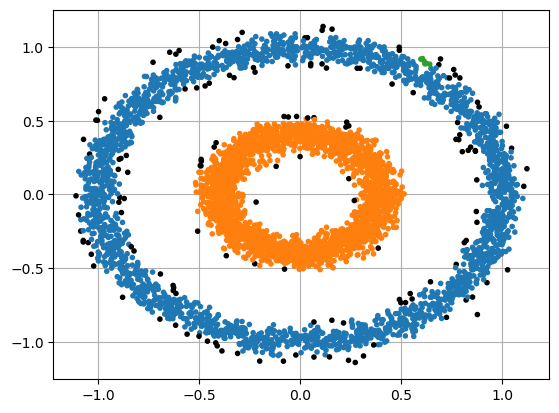

In [18]:
color_map = list(mcolors.TABLEAU_COLORS.keys())*1
labels = dbscan(points, eps=eps, min_pts=6)
colors = []
for lab in labels:
    if lab == 'Noise':
        colors.append('black')
    else: 
        colors.append(color_map[int(lab)])
plt.scatter([x for x,_ in points], [y for _,y in points], color=colors, marker='.', zorder=3)
plt.grid(True)